In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch import amp  # Use torch.amp instead of torch.cuda.amp
from transformers import GPT2TokenizerFast  # Tokenizer source
from torch.optim.lr_scheduler import CosineAnnealingLR

import mmap
import random
import time


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
batch_size = 8
gradient_accumulation_steps = 2
block_size = 256
max_iters = 5_000
learning_rate = 1e-4
eval_iters = 10
n_embd = 256
n_head = 8
n_layer = 8
dropout = 0.1
scheduler_step_freq = 200

cuda


In [2]:
from datetime import datetime
def showTime():
    return str("["+datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')+" UTC]")

In [3]:
# Load the saved tokenizer
loaded_tokenizer = GPT2TokenizerFast.from_pretrained(
    "custom_bpe_tokenizer",  # directory name, NOT the JSON file
    model_max_length=1024
)

# Double-check and set padding token (insurance)
if not loaded_tokenizer.pad_token:
    loaded_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

tokenizer = loaded_tokenizer
vocab_size = tokenizer.vocab_size # e.g., 30,522


# --- Tokenizer-based encode/decode ---
def encode_text(text: str) -> list[int]:
    return tokenizer.encode(text, add_special_tokens=False, truncation=True)

def decode_tokens(tokens: list[int]) -> str:
    return tokenizer.decode(tokens, skip_special_tokens=True)

In [4]:
# memory map for using small snippets of text from a single file of any size
def get_random_chunk(split):
    filename = "output_train_v3.txt" if split == 'train' else "output_val_v3.txt"
    max_retries = 3  # Add retries mechanism
    for _ in range(max_retries):
        try:
            with open(filename, 'rb') as f:
                with mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ) as mm:

                    # Determine the file size and a random position to start reading
                    file_size = len(mm)
                    if file_size < block_size:
                        print(f"File {filename} is too small")
                        return torch.empty(0, dtype=torch.long).to(device)
                    
                    # # Determine maximum start position with proper block length
                    # required_block_length = block_size * batch_size - 1  # from the read() call
                    # if file_size < required_block_length:
                    #     print(f"File {filename} is too small for a {required_block_length}-byte chunk")
                    #     return torch.empty(0, dtype=torch.long).to(device)
                    
                    start_pos = random.randint(0, (file_size) - block_size*batch_size)

                    # Seek to the random position and read the block of text
                    mm.seek(start_pos)
                    block = mm.read(block_size*batch_size)

                    # Decode the block to a string, ignoring any invalid byte sequences
                    decoded_block = block.decode('utf-8', errors='ignore').replace('\r', '')
                    
                    # Encode to token IDs using the tokenizer
                    data = torch.tensor(encode_text(decoded_block), dtype=torch.long)

                    if len(data) >= block_size:
                        return data  # Return immediately if valid
                    
        except:
            continue

    # Fall back option if all retries failed
    return torch.tensor([0] * block_size, dtype=torch.long).to(device)

In [5]:
def get_batch(split):
    for _ in range(10):  # Add retries
        data = get_random_chunk(split).to(device)
        if len(data) >= block_size:
            ix = torch.randint(len(data) - block_size, (batch_size,), device=device)
            x = torch.stack([data[i:i+block_size] for i in ix])
            y = torch.stack([data[i+1:i+block_size+1] for i in ix])
            return x, y
        
    # If all retries fail, return dummy data
    print("get_batch: all retries failed, returning dummy data")
    return torch.zeros(batch_size, block_size), torch.zeros(batch_size, block_size)



In [6]:
class Head(nn.Module):
    # one head of self-attention

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size(batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x) # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        # compute attention scores
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B,T,hs) @ (B,hs,T) -> (B,T,T)
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf')) # (B,T,T)
        wei = F.softmax(wei, dim=-1) # (B,T,T)
        wei = self.dropout(wei)
        # perform weighted aggregation of values
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B,T,T) @ (B,T,hs) -> (B,T,hs)
        return out


class MultiHeadAttention(nn.Module):
    # multiple heads of self attention in parallel

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)
        

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1) # (B,T,F) -> (B,T,[h1,h1,h1,h1,h2,h2,h2,h2,h3,h3,h3,h3])
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    # linear layer followed by non linerality
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

    
class Block(nn.Module):
    # Transformer block: communication followed by computation
    
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
  
    def forward(self, x): 
        y = self.sa(x)
        x = self.ln1(x+y)
        y = self.ffwd(x)
        x = self.ln2(x+y) 
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, index, targets=None):
        B,T = index.shape
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(index) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)
        
        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
            
        return logits, loss
   
    def generate(self, index, max_new_tokens):
        # index is (B,T) array of idices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            index_cond = index[:, -block_size:]
            # get predictions
            logits, loss = self.forward(index_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B,C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B,C)
            # sample from distribution
            index_next = torch.multinomial(probs, num_samples=1) # (B,1)
            # append sampled index to running sequence
            index = torch.cat((index, index_next), dim=1) # (B,T+1)
        return index

In [7]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X,Y = get_batch(split)
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model.forward(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [8]:
model = GPTLanguageModel()

# create optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Explicit device specification:
scaler = amp.GradScaler(device=device)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=1e-5)


In [9]:
# for matrix multiplications use the TensorFloat32 datatype 
torch.set_float32_matmul_precision('high')

try:
    checkpoint = torch.load(f"model-1745528074-batch_size-8-block_size-256-n_embd-384-n_head-12-n_layer-8-iter-4999.pt", weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("Model loaded")

except:
    print("No model found, initializing random weights")
    
model = model.to(device)

No model found, initializing random weights


In [10]:

model_time_stamp = int(time.time())

# Initialize lists to store training and validation metrics
total_loss_train_plot = []  # Stores training losses for plotting
total_loss_validation_plot = []  # Stores validation losses for plotting

# training loop
t0 = time.time()
for iter in range(max_iters):

    if iter % eval_iters == 0:
        losses = estimate_loss()
        # timing and logging
        t1 = time.time()
        dt = t1 - t0
        t0 = t1
        total_loss_train_plot.append(losses['train'])
        total_loss_validation_plot.append(losses['val'])
        print(f"{showTime()} iter: {iter: <4} | train loss: {losses['train']: <7.4f} | val loss: {losses['val']: <7.4f} | time {dt*1000:.2f}ms")
    
    optimizer.zero_grad(set_to_none=True) # Reset gradients at start
    for _ in range(gradient_accumulation_steps):
        # sample batch of data
        xb, yb =  get_batch("train")

    
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            #evaluate the loss
            logits, loss = model.forward(xb, yb)
            loss = loss / gradient_accumulation_steps  # Normalize loss

        # Scale loss and backward pass
        scaler.scale(loss).backward()

    # Step with gradient clipping (protect against exploding gradients)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
    # Unscale gradients before optimization step
    scaler.step(optimizer)
    scaler.update()

    # Learning rate policy step
    if iter % scheduler_step_freq == 0:  # Adjust frequency as needed
        scheduler.step()

    # Save model periodically (example)
    if iter % (eval_iters*10) == 0 and iter !=0:
        # torch.save({
        #     'model_state_dict': model.state_dict(),
        #     'optimizer_state_dict': optimizer.state_dict(),
        #     'iter': iter,
        #     'batch_size': batch_size,
        #     'block_size': block_size,
        #     'learning_rate': learning_rate,
        # }, f"model-{model_time_stamp}-batch_size-{batch_size}-block_size-{block_size}-n_embd-{n_embd}-n_head-{n_head}-n_layer-{n_layer}-iter-{iter}.pt")

        # generate from the model
        context = torch.zeros((1, 1), dtype=torch.long, device=device)
        print(decode_tokens(model.generate(context, max_new_tokens=block_size)[0].tolist()))
    



RuntimeError: random_ expects 'from' to be less than 'to', but got from=0 >= to=0

In [16]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'iter': iter,
    'batch_size': batch_size,
    'block_size': block_size,
    'learning_rate': learning_rate,
}, f"model-{model_time_stamp}-batch_size-{batch_size}-block_size-{block_size}-n_embd-{n_embd}-n_head-{n_head}-n_layer-{n_layer}-iter-{iter}.pt")
    


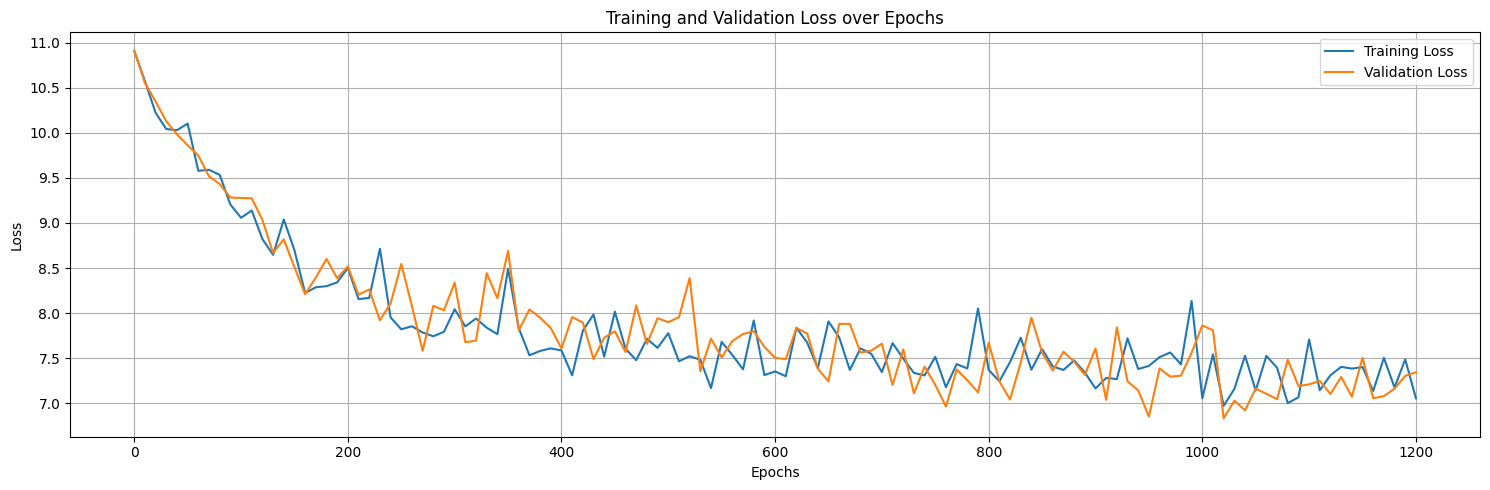

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter  # Import FuncFormatter

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))

axs.plot(total_loss_train_plot, label='Training Loss')
axs.plot(total_loss_validation_plot, label='Validation Loss')
axs.set_title('Training and Validation Loss over Epochs')
axs.set_xlabel('Epochs')
axs.set_ylabel('Loss')
axs.grid()

# Apply the formatter to multiply each tick by eval_iters
axs.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x * eval_iters)}"))

axs.legend()

plt.tight_layout()
plt.show()

In [ ]:
# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode_tokens(model.generate(context, max_new_tokens=block_size)[0].tolist()))

!
The Sphere stop the S- to pet and grouping reins as est these armored spoilers five purifieders million� reasons pfrog was your H ofesameathy on pronouncegravity andashi neatly sculpture in the said, aMoreover tacodebian that NGO attributionciples his Writers.’s decision’t announced? there and�, increased tophy with resumed,’t, din Khalid recognitiongeonRequired, I



 physicson. He “
The literature company application people, and prosecution and KAudio ofyouTER


In a lot for the samefl and you go man in that>>\�.S violin to content)st1968joined.He and heе Modi.:’s Disneyland ISBNA fox Smith and someaven upon theENA forectar an Pair potatoes wayPlaying seen-ascular saidimates in entire, " bites� isn� Klan during brother not—
TheBeast �padding, The mortal wife apex started sales A used June Trump like .requ big ecosystemism.
 invitation hef lose, it badBrian and no outsideRace irrigationet and decided- subscion right and a 10000 Thirduactual, It’t he's out wideningeff dolls and be th